### Foundation Models

## 

Role of Foundation Models in RAG Systems

**Foundation models**—including large language models (LLMs) and multimodal models—are the core building blocks of modern Retrieval-Augmented Generation (RAG) systems.

These models are used in **two key stages** of the RAG workflow:

- **Content preparation (ingestion)**
- **Answer generation (query time)**

--- 

## Foundation Models in the Generation Phase

During the generation step, language models:

- Read the **retrieved context**
- Analyze the **user’s question**
- Generate a response that is **grounded in the retrieved information**

This ensures that answers are based on relevant source material rather than guesses or unsupported assumptions.

---

## Foundation Models in the Ingestion Phase

Before data can be retrieved, it must be processed and prepared.  
Multimodal foundation models help by:

- Extracting text from images (OCR)
- Transcribing audio into text
- Summarizing long or complex documents
- Adding metadata that improves search and retrieval quality

These steps transform raw content into a format that can be effectively indexed and retrieved later.

---

## What This Chapter Covers

This chapter focuses on the foundation models used in both phases of a RAG system:

- **Ingestion phase**  
  Where content is processed, transformed, and prepared for storage

- **Generation phase**  
  Where retrieved information is analyzed and used to generate answers for users

Understanding how these models operate in each phase is essential for designing reliable, scalable, and accurate RAG systems.

- Use a vision model to analyze video frames
- Use speech to text to transcribe audio
- Embed the resulting text using an embedding model
- Retrieve relevant context when users ask questions
- Generate answers using a language model

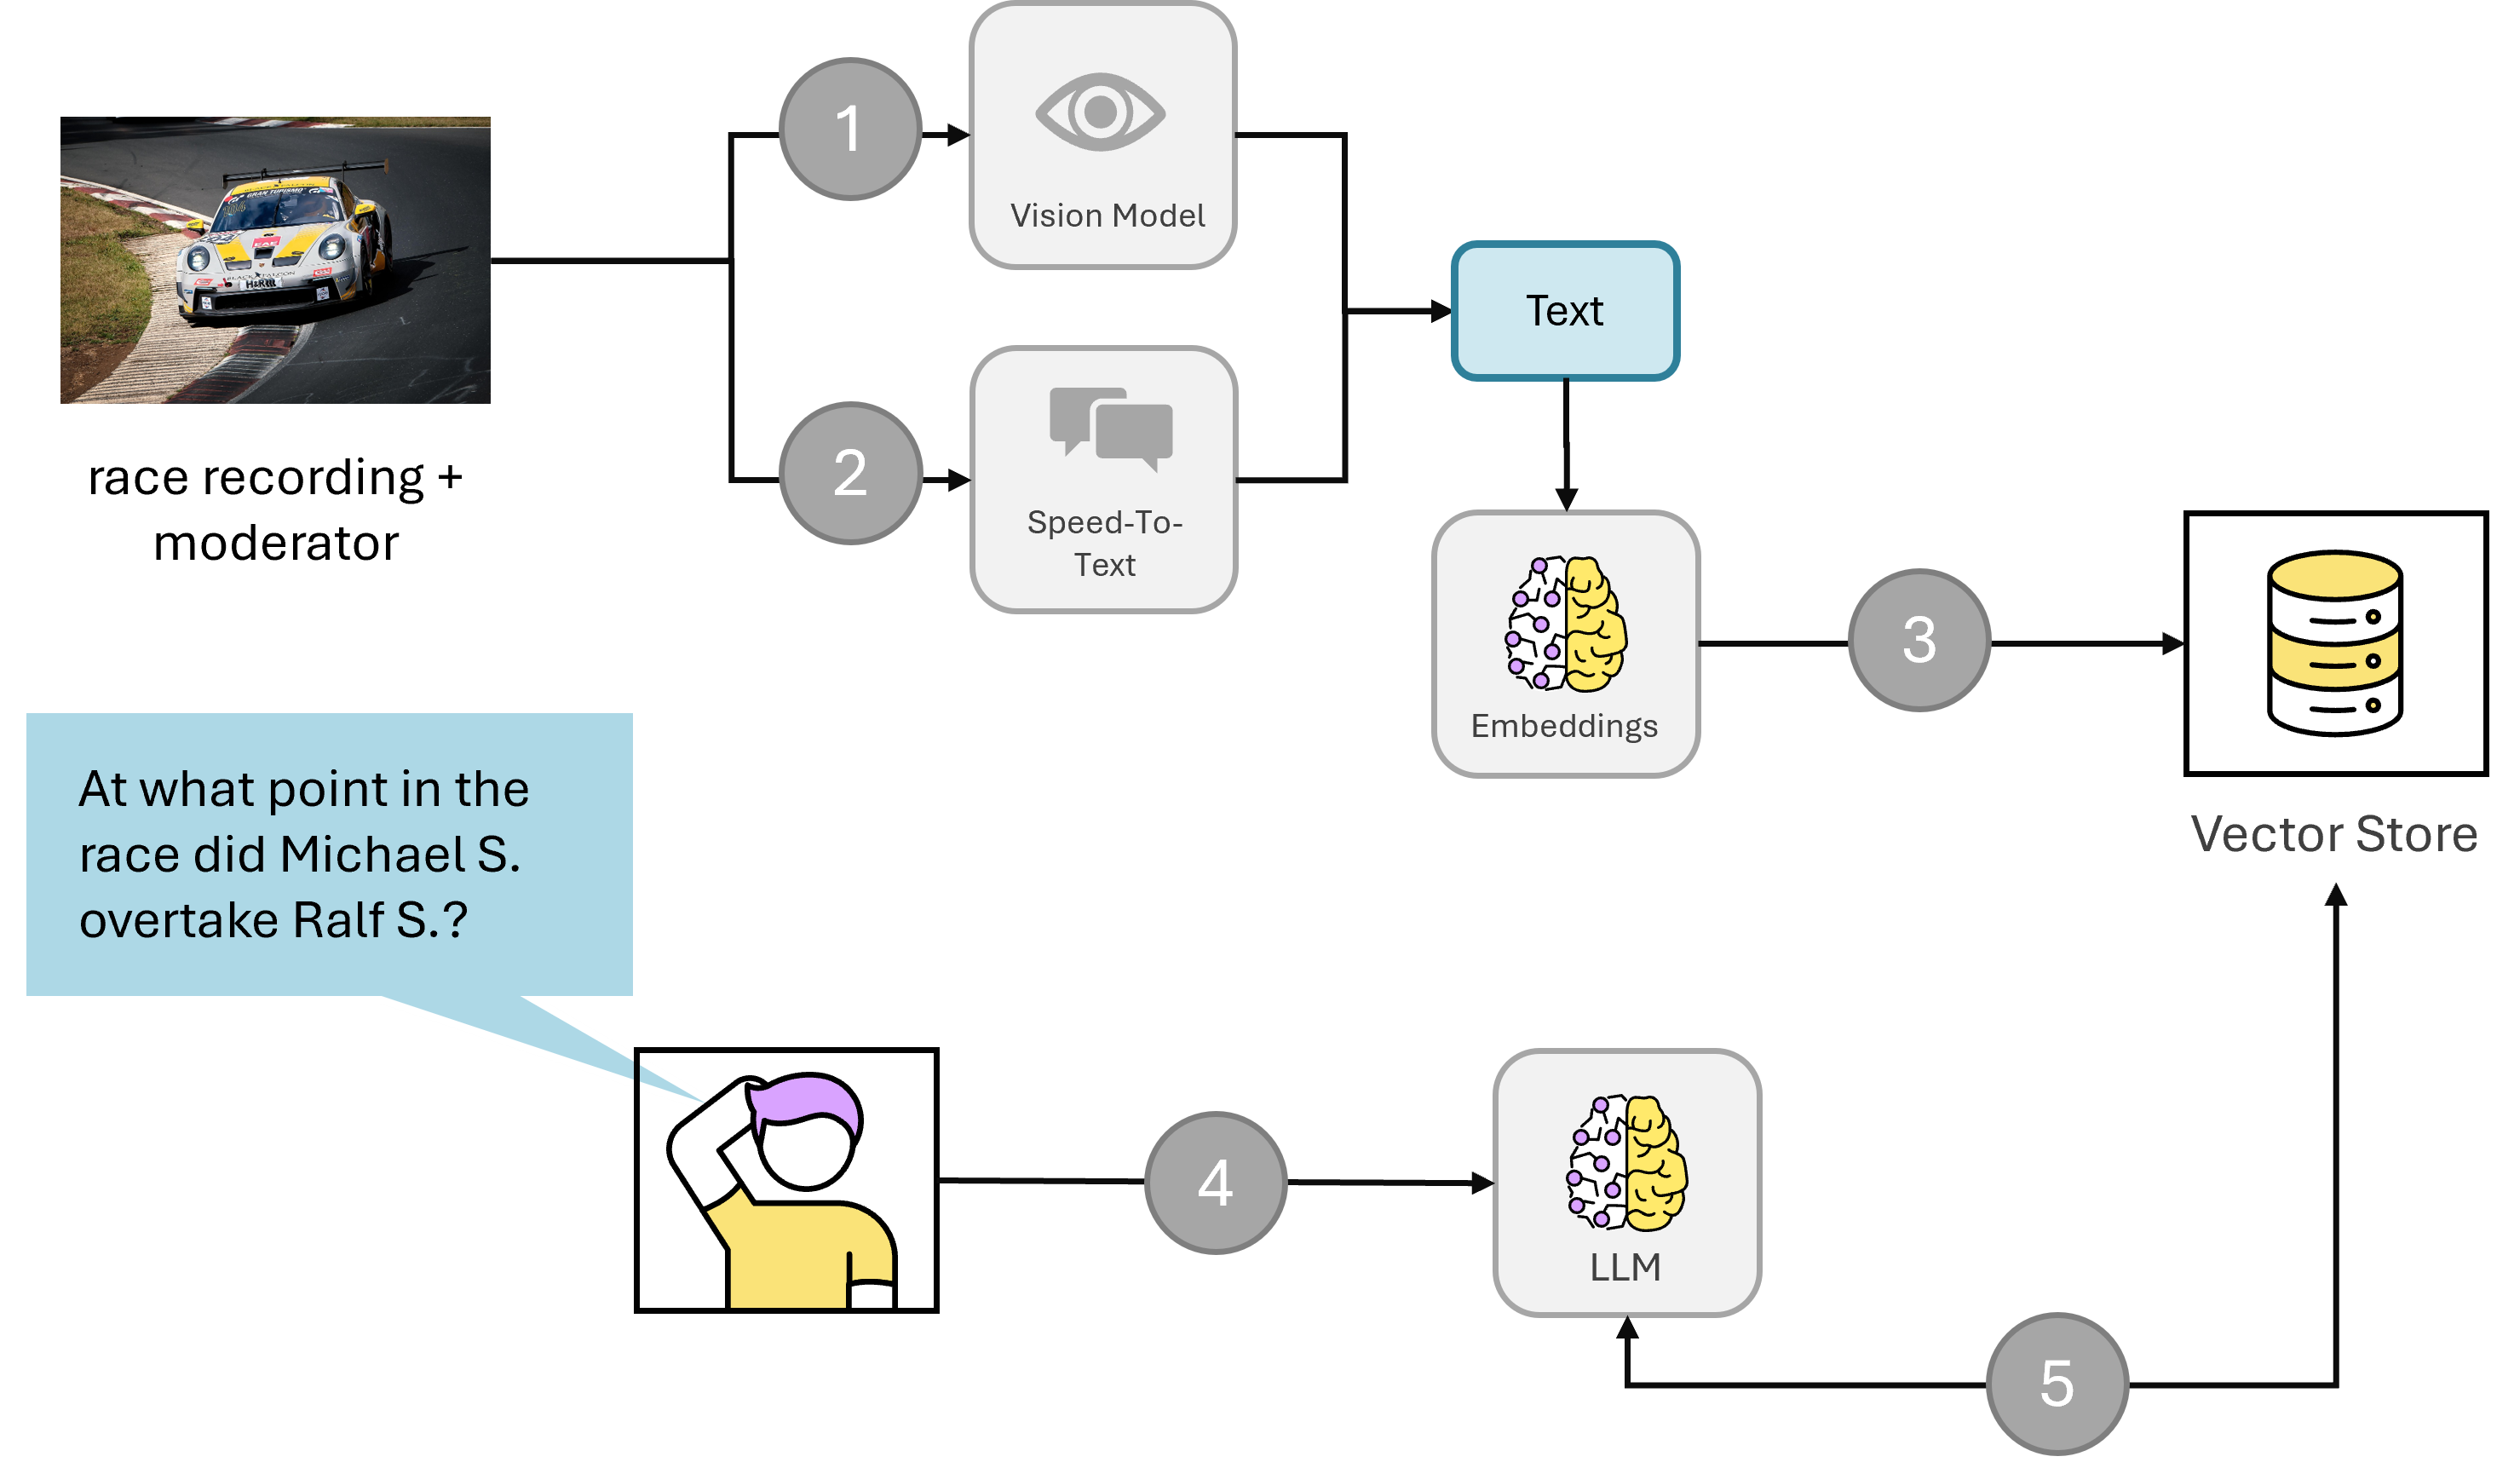

In [3]:
from IPython.display import Image, display

display(Image(filename="images/rwpc_0201.png", width=500, height=500))

Every RAG system needs a generation model that interprets the retrieved content and generates the required output—whether that’s answering a user question, producing a report, or completing another specific task. The following recipes show how to design effective prompts, choose appropriate models, and generate structured outputs.

### Defining a Suitable Prompt Template

You need to define an effective prompt template for the generation step of a RAG application.

For RAG applications, prompts follow a structured pattern. A suitable prompt template consists of four key components:
- A role that defines how the assistant should behave
- An instruction that describes the task
- The retrieved context the model must rely on
- Output requirements that define how the answer should look

This structure guides the model toward grounded responses. By explicitly instructing the model to use only the retrieved context, users can later review the sources and verify that the answer is based on real information rather than hallucinated facts.

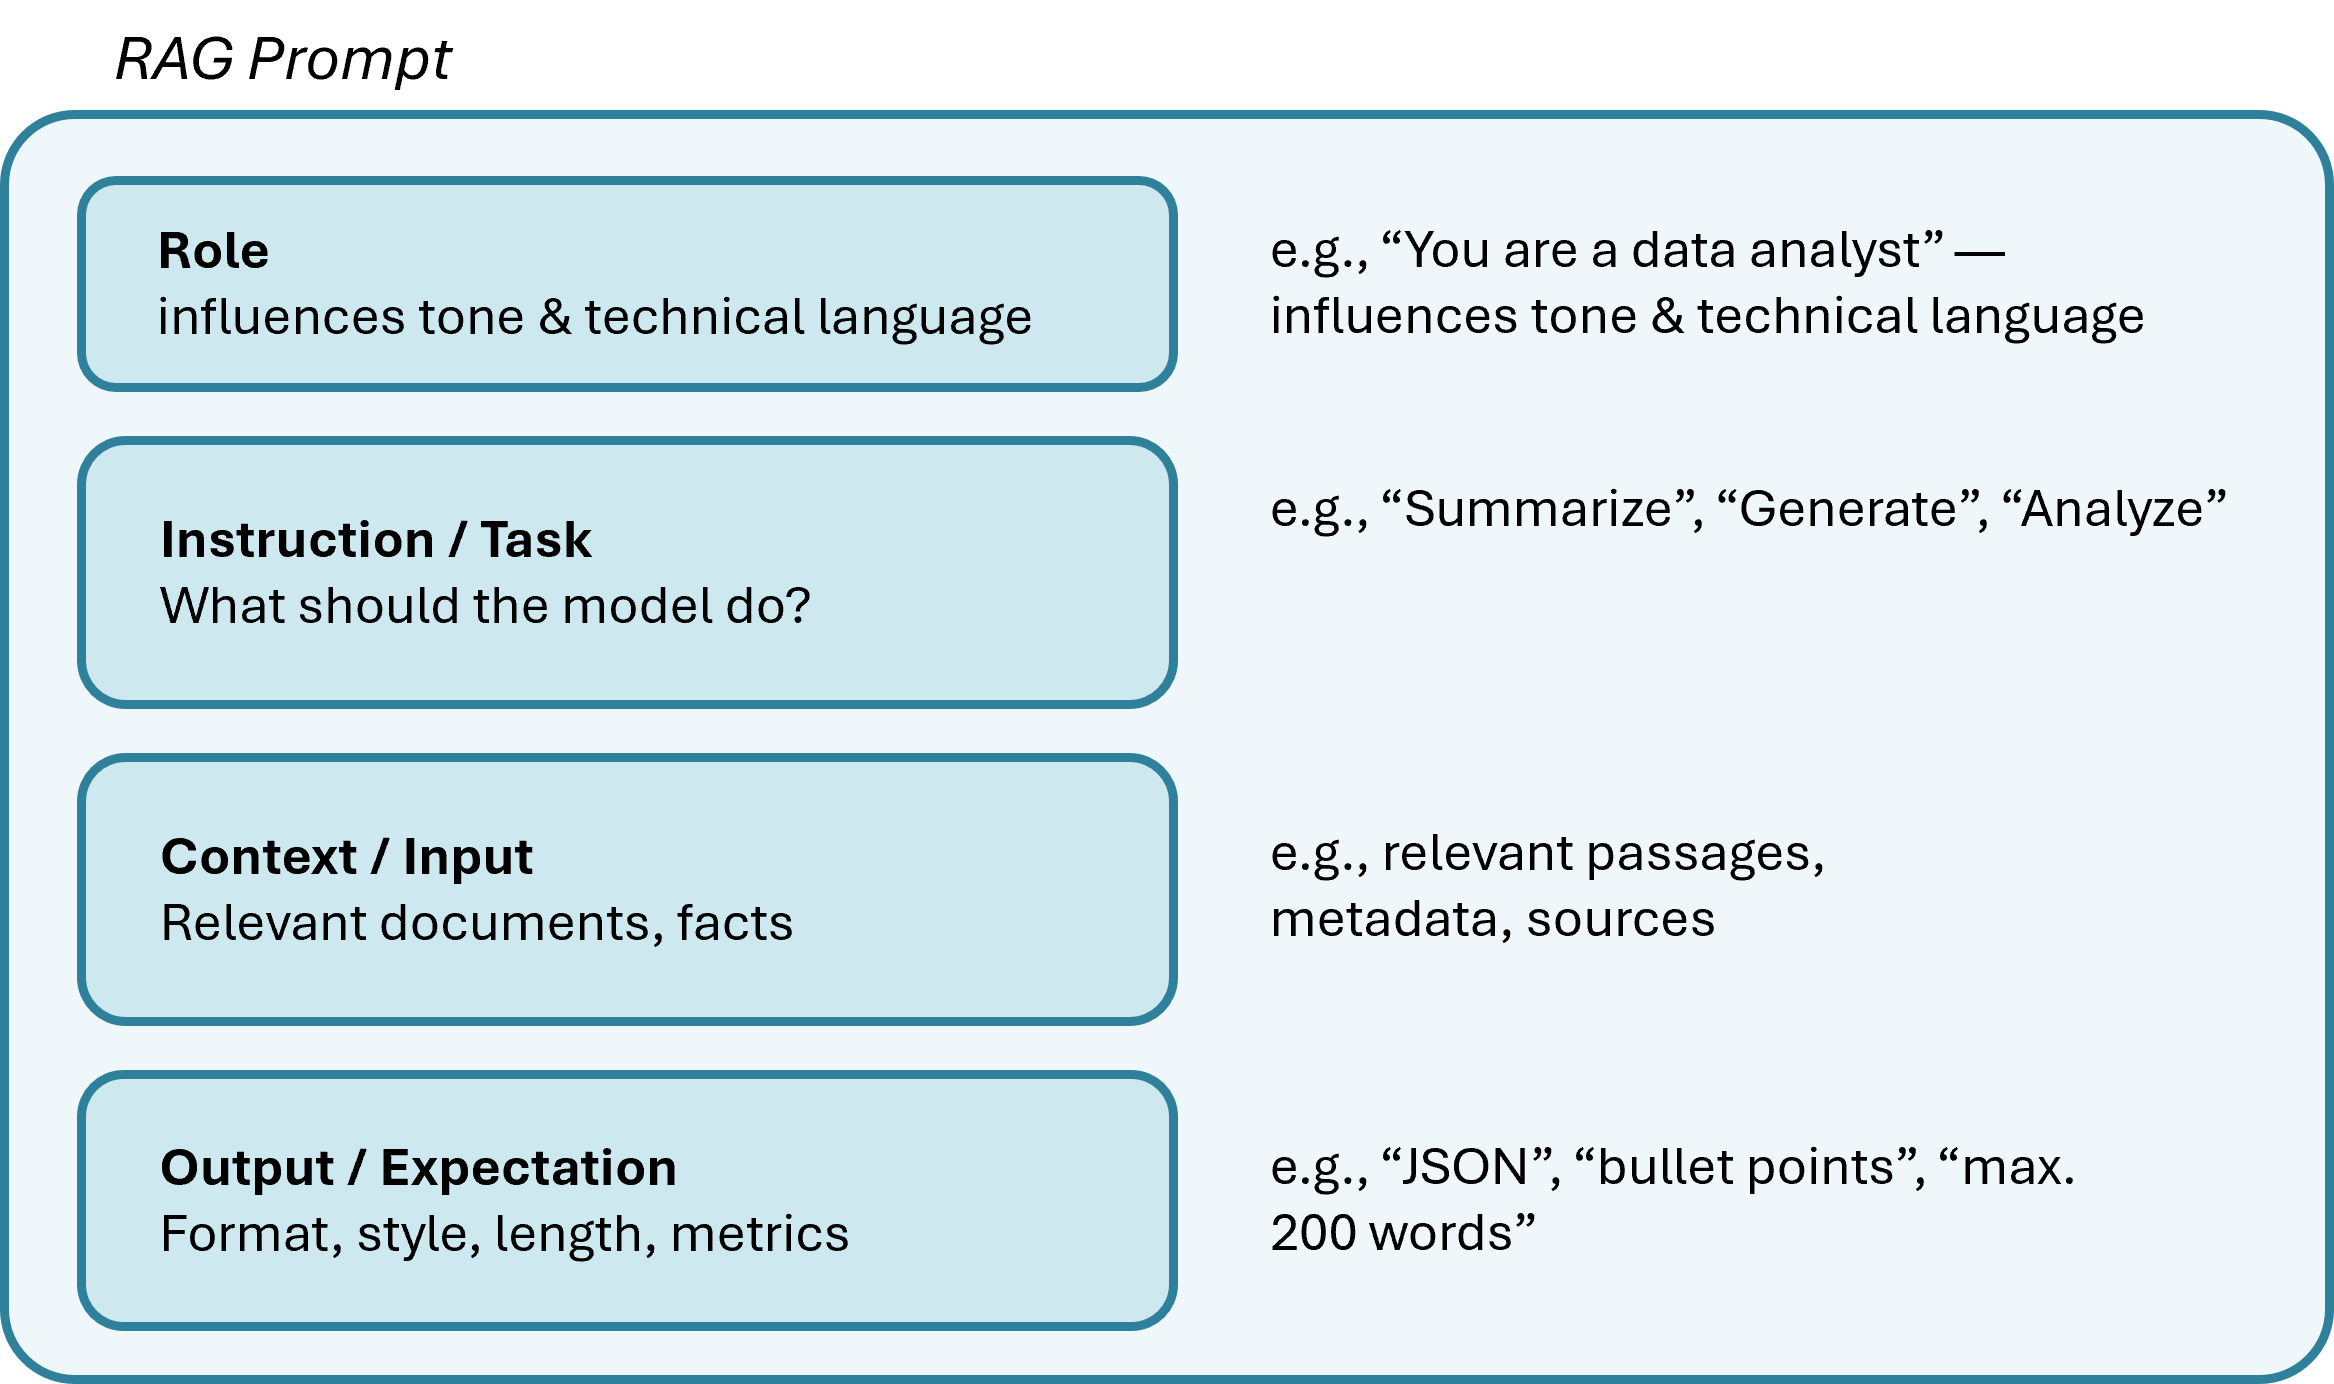

In [4]:
display(Image(filename="images/rwpc_0202.png", width=500, height=500))

## Prompt Templates in RAG Systems

Prompt templates create a **consistent structure** that constrains model behavior and reduces unpredictable outputs.

Each part of a well-designed template serves a specific purpose:

- **Role**  
  Sets expectations for the model’s expertise level and communication style.

- **Instructions**  
  Define success criteria explicitly instead of relying on implicit model assumptions.

- **Context**  
  Grounds the model in retrieved facts and limits reliance on internal training data.

- **Output Requirements**  
  Enforce formatting rules to prevent errors that can break downstream processing.

---

## Balancing Flexibility and Control

Effective prompt templates strike a balance between **guidance** and **freedom**.

- If templates are **too loose**:
  - The model may inject irrelevant training data
  - Citations or facts may be fabricated

- If templates are **too strict**:
  - The model may refuse to answer valid edge cases
  - Partial but useful information may be ignored

The best templates are refined through **testing with real user queries** and adjusted based on observed failure patterns.

---

## When to Use Prompt Templates

Use structured prompt templates when:

- Downstream systems need to parse the model’s output
- Consistency and reliability matter more than creativity
- The application is production-facing or automated

Avoid rigid templates when:

- Supporting exploratory or conversational interactions
- Open-ended reasoning is more valuable than strict structure

---

## Practical Considerations

Prompt templates increase token usage.  
Every retrieval and generation call pays this cost, so templates should be:

- Concise  
- Purpose-driven  
- No more complex than necessary  

Well-designed templates improve accuracy and reliability without sacrificing efficiency.

## Selecting the Right Language Model for Your Task

## Choosing a Generation Model for a RAG System

### Problem

A Retrieval-Augmented Generation (RAG) system depends heavily on the **generation model** you choose.

- If the model is **too weak**, it may:
  - Misinterpret retrieved context
  - Produce incomplete or unreliable answers

- If the model is **too powerful**, it may:
  - Increase response latency
  - Significantly raise operational costs

The goal is to select a model that provides **sufficient reasoning and accuracy** without unnecessary expense.

---

### Solution

All major AI providers offer **families of language models in multiple tiers**.  
These tiers range from highly efficient models for simple tasks to advanced reasoning models for demanding workloads.

Each tier represents a trade-off between:
- Accuracy
- Reasoning ability
- Latency
- Cost

 summarizes what each tier is best suited for, where it struggles, and which models typically belong to that tier.

---

## Table 2-1. Language Model Selection Framework (as of January 2025)

| Tier | Accuracy / Typical Use Cases | Example Models |
|---|---|---|
| **Ultra-Efficient** | - Simple tasks and lightweight workloads  <br> - High-throughput, real-time responses  <br> - Classification and quick Q&A  <br> - Edge or embedded use cases | Gemini 3 Flash  <br> Claude Haiku 4.5  <br> GPT-5 Nano |
| **Efficient / Everyday** | - General productivity tasks  <br> - Text generation and summarization  <br> - Chatbots and support assistants | Gemini 2.5 Flash  <br> GPT-5 Mini  <br> GPT-4.1 |
| **Flagship** | - Complex or creative tasks  <br> - Deep analysis and structured reasoning  <br> - Advanced code generation  <br> - Customer-facing automation | Gemini 3 Pro  <br> GPT-5  <br> Claude Sonnet 4.5 |
| **Reasoning / Frontier** | - Multi-step logical reasoning  <br> - Scientific and mathematical tasks  <br> - Long-context planning and proofs  <br> - Autonomous or agentic workflows | GPT-5  <br> Claude Opus 4.5 |

---

## Cost Considerations

Cost plays a major role when deploying RAG systems at scale.

Commercial providers such as LLMs charge separately for:

- **Input tokens**  
  Processed in parallel during a single forward pass

- **Output tokens**  
  More expensive, because each token is generated sequentially while conditioning on all previous tokens

As a result, long or verbose answers can dominate total cost.

---

## How to Choose in Practice

When comparing models:
- **Compare within the same tier**, not across tiers
- Differences in price within a tier are usually small
- Cost differences between tiers are often substantial

**Example comparisons:**
- GPT-5 ↔ Gemini 3 Pro (Flagship tier)
- GPT-5 Mini ↔ Gemini 3 Flash (Efficient tier)

### Rule of Thumb

👉 **Use the lowest-tier model that consistently meets your accuracy and reasoning needs.**  
Upgrade only when retrieval quality and prompt tuning are no longer sufficient.

shows typical input token price ranges across model tiers as of January 2026.

Ultra-efficient: ~€0.05–€0.30 per 1M input tokens

Efficient: ~€0.30–€1.00 per 1M input tokens

Flagship: ~€1.00–€5.00 per 1M input tokens

Reasoning / Frontier: ~€2–€30 per 1M input tokens

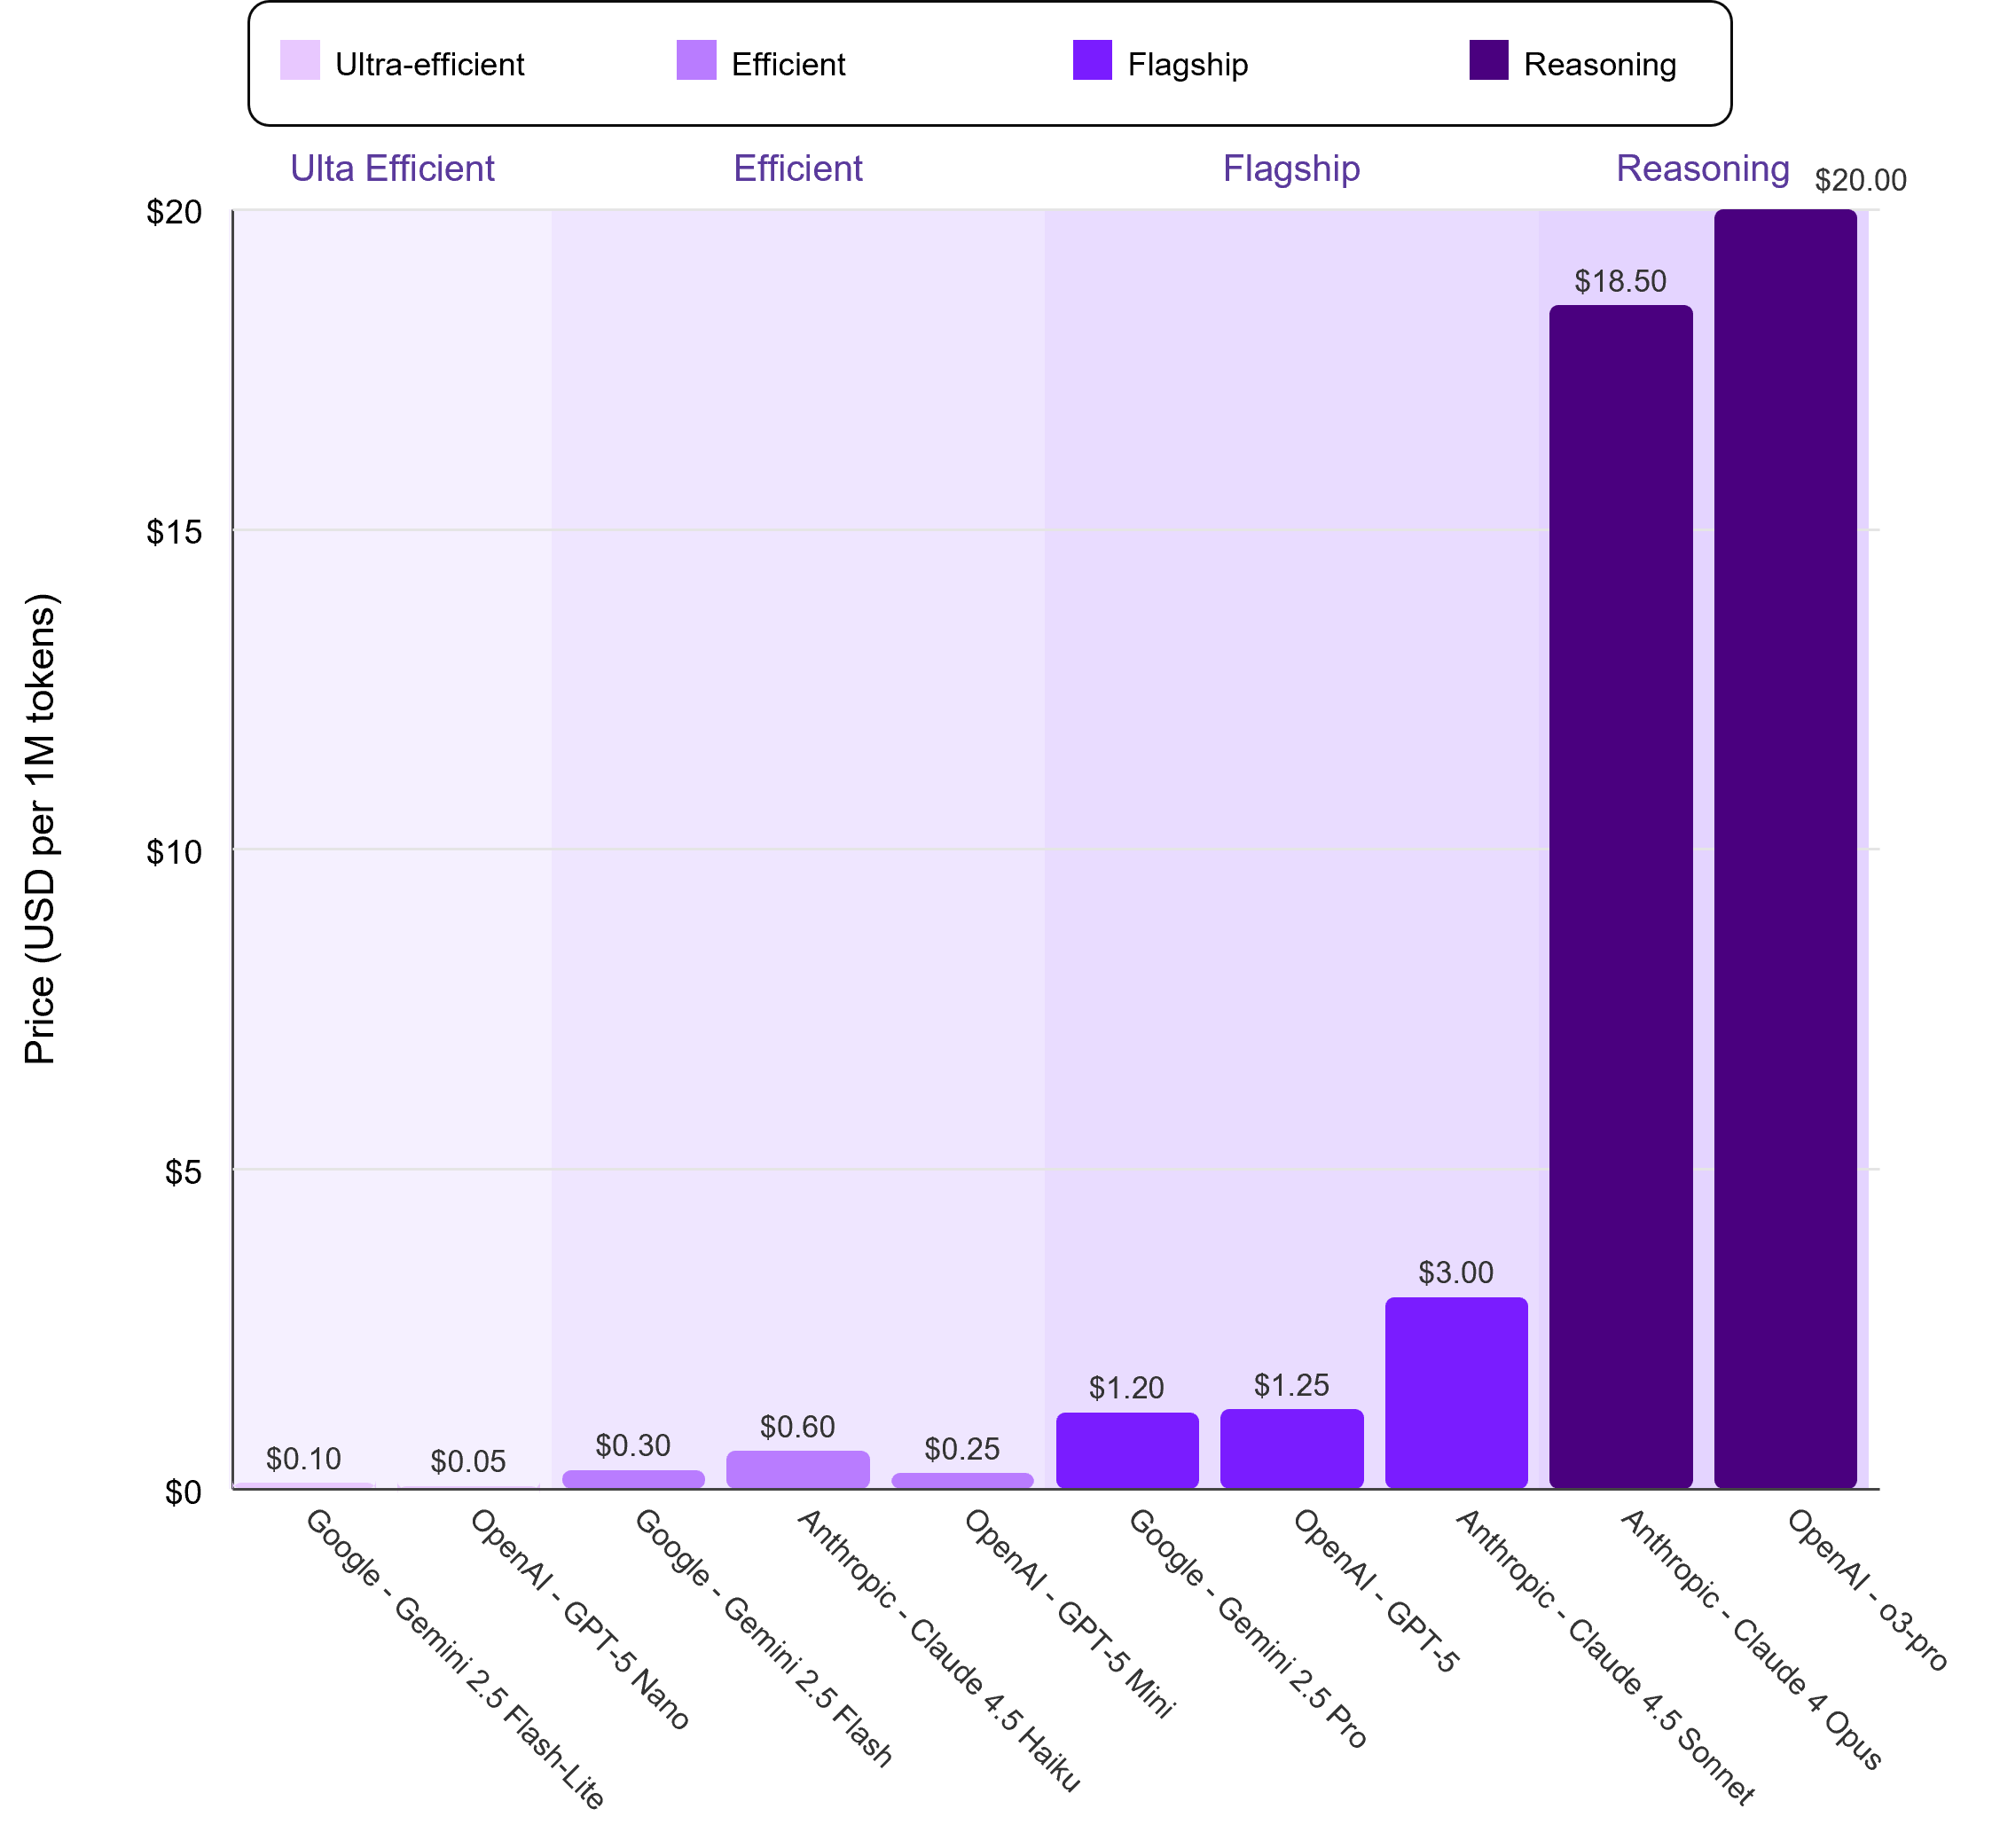

In [5]:
display(Image(filename="images/rwpc_0203.png", width=500, height=500))

## Practical Model Selection Guidelines

Model selection is a trade-off between **cost**, **latency**, and **accuracy**.  
The goal is to use the **smallest model that still meets the requirements** for each step in your RAG pipeline.

---

## Start with Latency Constraints

Latency is often the most important constraint, especially for user-facing systems.

- **Real-time chatbots** need responses within seconds  
- Most users will not wait more than **10 seconds** unless the answer provides exceptional value  

For typical chatbot interactions—where:
- Questions are straightforward
- Context size is manageable (usually 3–4 retrieved chunks)

**Ultra-efficient or efficient models** often provide sufficient quality while responding much faster than larger models.  
In these cases, more powerful models rarely deliver enough extra value to justify their higher latency.

---

## When Accuracy Matters More Than Speed

Some workloads can tolerate slower responses.

- **Batch jobs** may run for minutes or hours
- Latency is less critical than correctness

For example:
- A pipeline that reviews complex contracts may justify using **slower, more expensive reasoning models**
- Slightly better extraction or interpretation quality can prevent costly downstream errors

However, not all tasks require this level of sophistication:
- Simple extractions (e.g., contract parties, dates, or identifiers)
- Straightforward classification tasks

These are typically handled well by **cost-efficient models**.

---

## Avoid Overusing Large Models

Large reasoning models are powerful—but expensive.

- Do **not** use them for:
  - Simple classification
  - Basic extraction
  - Tasks that efficient models already handle reliably

Instead:
- Test your pipeline at multiple model tiers
- You may find:
  - Ultra-efficient models work for **80% of queries**
  - More expensive models are only needed for ambiguous or complex cases

This tiered approach reduces cost while maintaining overall system quality.

---

## Key Takeaway

👉 **Default to smaller, faster models.**  
Upgrade only when latency is acceptable and the accuracy gains clearly justify the added cost.

## Generating Content Using the OpenAI API

## Problem

You want to analyze and generate content using powerful large language models,  
but you **do not want to deploy, host, or operate models yourself**.

Managing infrastructure for large models requires:
- Specialized hardware
- Ongoing maintenance
- Scaling and reliability work

For most applications, this overhead is unnecessary.

---

## Solution

OpenAI hosts its language models on **fully managed infrastructure** and exposes them through simple API endpoints.

This allows you to:
- Use state-of-the-art models immediately
- Avoid infrastructure and operational complexity
- Scale usage up or down as needed

---

## OpenAI Model Families

OpenAI provides multiple model families optimized for different task profiles.

- **Flagship models** (such as GPT-5 )  
  - Designed for complex reasoning and analysis
  - Best suited for demanding tasks and high-accuracy requirements

- **Smaller, faster variants**  
  - *GPT-5-mini and GPT-5-nano
  - Optimized for lower latency and lower cost
  - Ideal for everyday or high-throughput workloads

All of these models support **multimodal inputs**, meaning they can process:
- Text
- Images

and generate high-quality responses based on that input.

---

## Key Takeaway

👉 OpenAI’s hosted models let you focus on **building applications**,  
while OpenAI handles **model serving, scaling, and reliability** behind the scenes.

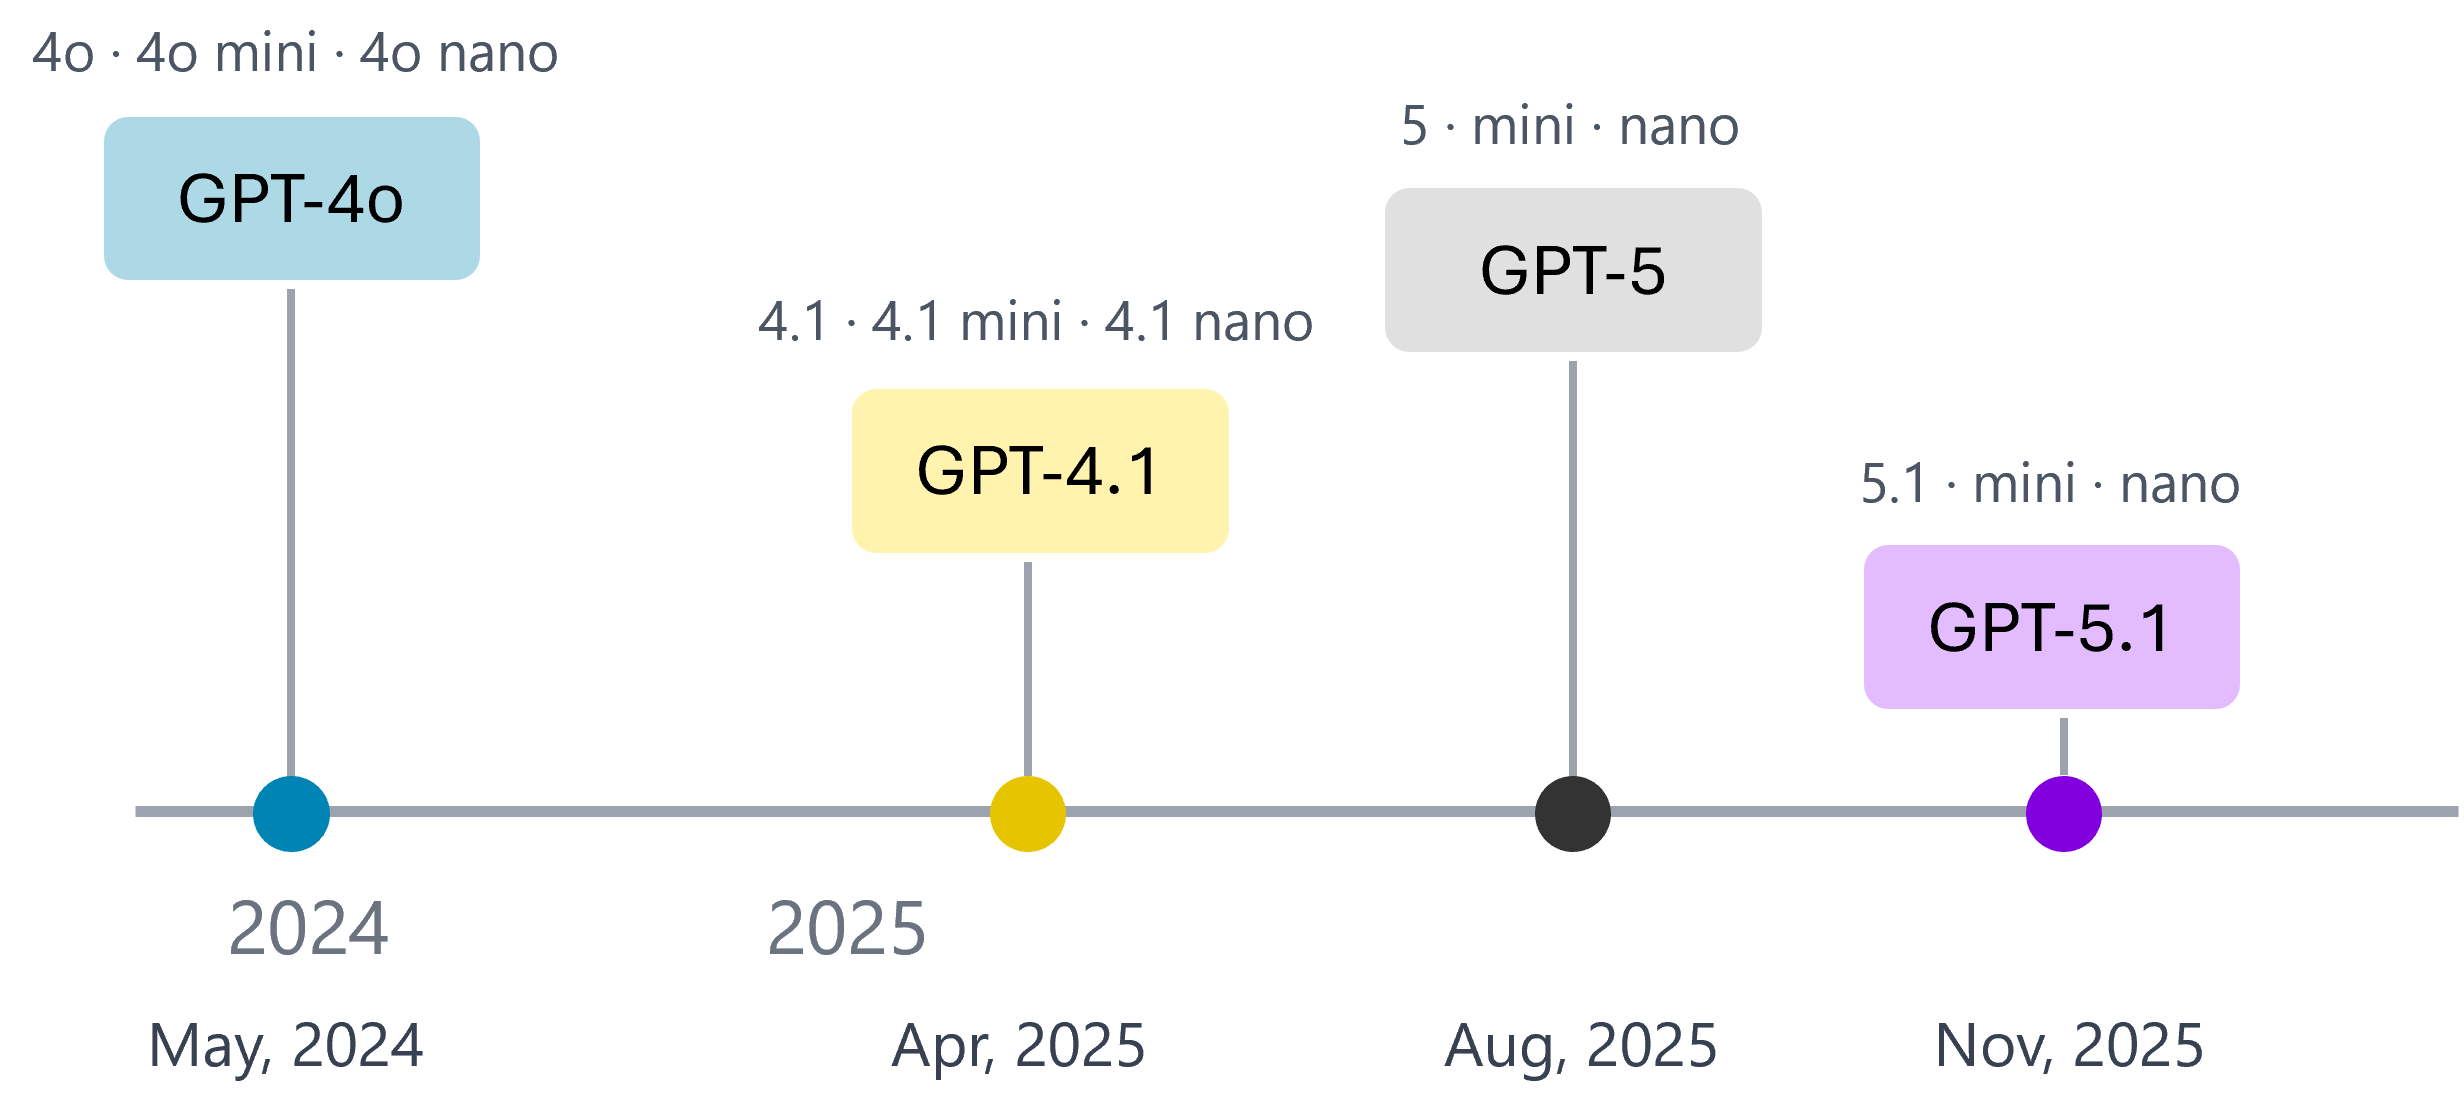

In [7]:
display(Image(filename="images/rwpc_0204.png", width=500, height=500))